In [1]:
import pandas as pd
import numpy as np

import os

def load_hotel_reserve():
  customer_tb = pd.read_csv('./data/customer.csv')
  hotel_tb = pd.read_csv('./data/hotel.csv')
  reserve_tb = pd.read_csv('./data/reserve.csv')
  return customer_tb, hotel_tb, reserve_tb


def load_holiday_mst():
  holiday_tb = pd.read_csv('./data/holiday_mst.csv',index_col=False)
  return holiday_tb


def load_production():
  production_tb = pd.read_csv('./data/production.csv')
  return production_tb


def load_production_missing_num():
  production_tb = pd.read_csv('./data/production_missing_num.csv')
  return production_tb


def load_production_missing_category():
  production_tb = pd.read_csv('./data/production_missing_category.csv')
  return production_tb


def load_monthly_index():
  monthly_index_tb = \
    pd.read_csv('./data/monthly_index.csv')
  return monthly_index_tb


def load_meros_txt():
  with open('./data/txt/meros.txt', 'r') as f:
    meros = f.read()
    f.close()
  return meros


In [19]:
customer_tb, hotel_tb, reserve_tb = load_hotel_reserve()

rb = reserve_tb.query('people_num == 1')
ht = hotel_tb.query('is_business == 1')
record = pd.merge(rb, ht, on='hotel_id', how='inner')

print(record['checkin_date'])


0      2018-01-25
1      2016-12-08
2      2017-10-21
3      2016-11-12
4      2016-04-07
          ...    
441    2016-07-04
442    2017-02-10
443    2016-04-02
444    2017-09-07
445    2016-07-06
Name: checkin_date, Length: 446, dtype: str


In [26]:
# 예약 테이블과 호텔 테이블을 결합해 숙박 인원수가 한 명인 비지니스 예약 레코드를 추출해본다

rb = reserve_tb.query('people_num == 1')
ht = hotel_tb.query('is_business == 1')
record = pd.merge(rb, ht, on='hotel_id', how='inner')
print(record['checkin_date'])

0      2018-01-25
1      2016-12-08
2      2017-10-21
3      2016-11-12
4      2016-04-07
          ...    
441    2016-07-04
442    2017-02-10
443    2016-04-02
444    2017-09-07
445    2016-07-06
Name: checkin_date, Length: 446, dtype: str


Axes(0.125,0.11;0.775x0.77)


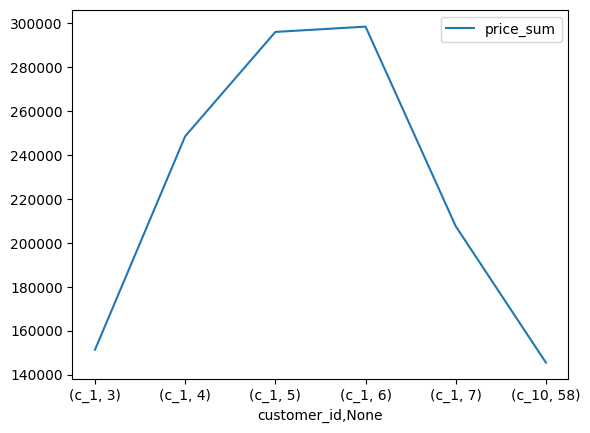

In [55]:
# 예약 테이블의 모든 행에 자신의 행에서 같은 고객의 이전 예약 세 건의 예약 금액 정보를 추출한 합계

record = pd.merge(reserve_tb, hotel_tb, on='hotel_id', how='inner') \
  .groupby('customer_id') \
    .apply(lambda x: x.sort_values('reserve_datetime', ascending=True)) # 예약 시간 기준으로 정렬
    
# price_sum 컬럼 생성
record['price_sum'] = (
  record.groupby(level='customer_id')['total_price']
      .rolling(3, min_periods=3)
      .sum()
      .shift(1)
      .reset_index(level=0, drop=True)
)

print(record.head(10).plot(y='price_sum', kind='line'))


In [56]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.3 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 24.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------- ----------------------------- 9.7/37.3 MB 46.2 MB/s eta 0:00:01
   ------------- -------------------------- 12.6/37.3 MB 46.9 MB/s eta 0:00:01
   -------------- ------------------------- 13.9/37.3 MB 22.4 MB/s eta 0:00:02
   ------------------------ --------------- 23.1/37.3 MB 29.6 MB/s eta 0:00:01
   -------------------------------- ------- 29.9/37.3 MB 29.1 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 31.0 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 29.4 MB/s  0:00:01

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
